In [1]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()
print("Connected.")

Connected.


In [2]:
tables = [
    ('int', 'int_game_team_features'),
    ('int', 'int_team_season_context'),
]

for schema, table in tables:
    cur.execute(f"""
        SELECT column_name, data_type
        FROM information_schema.columns
        WHERE table_schema = '{schema}' AND table_name = '{table}'
        ORDER BY ordinal_position
    """)
    rows = cur.fetchall()
    print(f"\n{'='*60}")
    print(f"{schema}.{table} — {len(rows)} columns")
    print('='*60)
    for col, dtype in rows:
        print(f"  {col:<45} {dtype}")


int.int_game_team_features — 28 columns
  game_id                                       bigint
  season                                        integer
  week                                          integer
  game_date                                     date
  team_name                                     text
  opponent                                      text
  points_scored                                 integer
  points_allowed                                integer
  win                                           integer
  off_epa_per_play                              numeric
  def_epa_per_play_allowed                      numeric
  close_game_epa_per_play                       numeric
  close_game_play_count                         bigint
  close_game_def_epa_per_play                   numeric
  close_game_def_play_count                     bigint
  game_script                                   text
  game_script_avg_margin                        numeric
  last3_off_epa_avg   

In [3]:
query = """
    SELECT
        f.game_id,
        f.season,
        f.week,
        f.team_name,
        f.opponent,
        f.points_scored,
        f.points_allowed,
        f.win,
        f.off_epa_per_play,
        f.close_game_epa_per_play,
        f.close_game_def_epa_per_play,
        f.close_game_play_count,
        f.opp_sp_rating_at_game_time,
        f.pregame_elo,
        f.opponent_pregame_elo,
        f.postgame_elo,
        f.excitement_index,
        c.conference
    FROM int.int_game_team_features f
    JOIN int.int_team_season_context c
        ON f.team_name = c.team_name AND f.season = c.season
    WHERE f.pregame_elo IS NOT NULL
"""

cur.execute(query)
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
df = pd.DataFrame(rows, columns=cols)

numeric_cols = [
    'points_scored', 'points_allowed', 'win', 'off_epa_per_play',
    'close_game_epa_per_play', 'close_game_def_epa_per_play',
    'close_game_play_count', 'opp_sp_rating_at_game_time',
    'pregame_elo', 'opponent_pregame_elo', 'postgame_elo', 'excitement_index'
]
df[numeric_cols] = df[numeric_cols].astype(float)
df['point_differential'] = df['points_scored'] - df['points_allowed']

print(f"Rows: {len(df):,}")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Teams: {df['team_name'].nunique()}")
print(f"Excitement index coverage: {df['excitement_index'].notna().sum():,} / {len(df):,} ({df['excitement_index'].notna().mean():.1%})")
print(f"\nConference value counts:")
print(df['conference'].value_counts())

Rows: 6,478
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Teams: 136
Excitement index coverage: 6,475 / 6,478 (100.0%)

Conference value counts:
conference
Big Ten              776
ACC                  749
SEC                  727
Big 12               680
Sun Belt             677
American Athletic    644
Mid-American         596
Mountain West        585
Conference USA       513
Pac-12               340
FBS Independents     191
Name: count, dtype: int64


In [4]:
P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row["team_name"] == "Notre Dame":
        return "P4"
    if row["team_name"] == "UConn":
        return "G5"
    if row["conference"] in P4_CONFERENCES:
        return "P4"
    return "G5"

df['tier'] = df.apply(assign_tier, axis=1)

# Load season-level SP+ for divergence — need sp_rating at season level
query2 = """
    SELECT team_name, season, sp_rating, off_epa_per_play, def_epa_per_play,
           win_pct, games_played
    FROM int.int_team_season_context
"""
cur.execute(query2)
rows2 = cur.fetchall()
cols2 = [d[0] for d in cur.description]
sp = pd.DataFrame(rows2, columns=cols2)
sp_numeric = ['sp_rating', 'off_epa_per_play', 'def_epa_per_play', 'win_pct', 'games_played']
sp[sp_numeric] = sp[sp_numeric].astype(float)

print(f"SP+ season rows: {len(sp):,}")
print(f"SP+ null count: {sp['sp_rating'].isna().sum()}")
print(sp[['sp_rating', 'off_epa_per_play', 'def_epa_per_play']].describe().round(3))

SP+ season rows: 534
SP+ null count: 0
       sp_rating  off_epa_per_play  def_epa_per_play
count    534.000           534.000           534.000
mean       0.492             0.177             0.156
std       12.993             0.091             0.079
min      -36.600            -0.066            -0.078
25%       -9.175             0.113             0.101
50%        1.250             0.175             0.154
75%        9.400             0.237             0.210
max       35.300             0.483             0.402


In [5]:
# Aggregate game-level ELO to team-season level
# Use mean pregame_elo per team-season (ELO mid-season position)
elo_season = (
    df.groupby(['team_name', 'season'])
    .agg(
        mean_pregame_elo=('pregame_elo', 'mean'),
        last_pregame_elo=('pregame_elo', 'last'),   # end-of-season proxy
        last_postgame_elo=('postgame_elo', 'last'),
        elo_game_count=('pregame_elo', 'count')
    )
    .reset_index()
)

# Merge SP+ onto ELO season frame
ts = elo_season.merge(sp, on=['team_name', 'season'], how='inner')
print(f"Team-seasons with both ELO and SP+: {len(ts):,}")
print(f"Seasons: {sorted(ts['season'].unique())}")

# Normalize both to z-scores within season before computing divergence
# This puts ELO and SP+ on the same scale
for col in ['mean_pregame_elo', 'sp_rating']:
    ts[f'{col}_z'] = ts.groupby('season')[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

# Divergence = ELO z-score minus SP+ z-score
# Positive: ELO rates team higher than SP+ implies
# Negative: SP+ rates team higher than ELO implies
ts['elo_sp_divergence'] = ts['mean_pregame_elo_z'] - ts['sp_rating_z']

print(f"\nDivergence stats:")
print(ts['elo_sp_divergence'].describe().round(3))
print(f"\nTop 10 positive divergence (ELO > SP+):")
print(ts.nlargest(10, 'elo_sp_divergence')[['team_name', 'season', 'mean_pregame_elo', 'sp_rating', 'elo_sp_divergence']].to_string(index=False))
print(f"\nTop 10 negative divergence (SP+ > ELO):")
print(ts.nsmallest(10, 'elo_sp_divergence')[['team_name', 'season', 'mean_pregame_elo', 'sp_rating', 'elo_sp_divergence']].to_string(index=False))

Team-seasons with both ELO and SP+: 534
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Divergence stats:
count    534.000
mean       0.000
std        0.436
min       -1.238
25%       -0.284
50%        0.007
75%        0.300
max        1.443
Name: elo_sp_divergence, dtype: float64

Top 10 positive divergence (ELO > SP+):
        team_name  season  mean_pregame_elo  sp_rating  elo_sp_divergence
           Nevada    2022       1444.833333      -22.4           1.442737
   Kennesaw State    2024       1326.000000      -25.1           1.221745
       Notre Dame    2025       2181.250000       24.4           1.086215
 Western Kentucky    2022       1739.538462        1.7           0.989434
      Sam Houston    2025       1216.583333      -27.8           0.941946
         Michigan    2024       1877.750000       10.6           0.913391
       Penn State    2025       2022.000000       18.1           0.886134
         Colorado    2025       1546.250000       -8.3    

In [6]:
# Shift divergence forward one season to test YoY stability
ts_sorted = ts.sort_values(['team_name', 'season'])
ts_sorted['divergence_next'] = ts_sorted.groupby('team_name')['elo_sp_divergence'].shift(-1)
ts_sorted['sp_rating_next'] = ts_sorted.groupby('team_name')['sp_rating'].shift(-1)
ts_sorted['win_pct_next'] = ts_sorted.groupby('team_name')['win_pct'].shift(-1)

yoy = ts_sorted.dropna(subset=['divergence_next', 'sp_rating_next', 'win_pct_next'])
print(f"YoY pairs: {len(yoy):,}")

# YoY stability of divergence itself
r_div_yoy, p_div_yoy = stats.pearsonr(yoy['elo_sp_divergence'], yoy['divergence_next'])
print(f"\nDivergence YoY stability: r={r_div_yoy:.3f}, p={p_div_yoy:.4f}")

# Does divergence predict next-season win_pct beyond SP+?
# Partial r: residualize both divergence and win_pct_next on sp_rating (current)
def partial_r(df, x_col, y_col, control_col):
    valid = df[[x_col, y_col, control_col]].dropna()
    res_x = stats.linregress(valid[control_col], valid[x_col])
    res_y = stats.linregress(valid[control_col], valid[y_col])
    x_resid = valid[x_col] - (res_x.slope * valid[control_col] + res_x.intercept)
    y_resid = valid[y_col] - (res_y.slope * valid[control_col] + res_y.intercept)
    r, p = stats.pearsonr(x_resid, y_resid)
    return r, p

r_partial_winpct, p_partial_winpct = partial_r(yoy, 'elo_sp_divergence', 'win_pct_next', 'sp_rating')
r_partial_sp, p_partial_sp = partial_r(yoy, 'elo_sp_divergence', 'sp_rating_next', 'sp_rating')

print(f"\nPartial r (divergence → next win_pct | controlling SP+): r={r_partial_winpct:.3f}, p={p_partial_winpct:.4f}")
print(f"Partial r (divergence → next SP+      | controlling SP+): r={r_partial_sp:.3f}, p={p_partial_sp:.4f}")

# Benchmark: SP+ alone predicting next win_pct
r_sp_winpct, p_sp_winpct = stats.pearsonr(yoy['sp_rating'], yoy['win_pct_next'])
print(f"\nBenchmark — SP+ → next win_pct: r={r_sp_winpct:.3f}, p={p_sp_winpct:.4f}")

YoY pairs: 398

Divergence YoY stability: r=0.108, p=0.0311

Partial r (divergence → next win_pct | controlling SP+): r=0.059, p=0.2442
Partial r (divergence → next SP+      | controlling SP+): r=0.078, p=0.1216

Benchmark — SP+ → next win_pct: r=0.496, p=0.0000


In [7]:
# Filter to games with excitement index available
df_exc = df[df['excitement_index'].notna()].copy()
print(f"Games with excitement index: {len(df_exc):,}")
print(f"Seasons covered: {sorted(df_exc['season'].unique())}")
print(f"Coverage by season:")
print(df.groupby('season')['excitement_index'].apply(lambda x: f"{x.notna().sum()}/{len(x)} ({x.notna().mean():.1%})"))

# Aggregate to team-season
exc_season = (
    df_exc.groupby(['team_name', 'season'])
    .agg(
        avg_excitement_index=('excitement_index', 'mean'),
        pct_games_high_excitement=('excitement_index', lambda x: (x >= 6.0).mean()),
        excitement_game_count=('excitement_index', 'count')
    )
    .reset_index()
)

print(f"\nTeam-seasons with excitement data: {len(exc_season):,}")
print(f"\nExcitement index distribution:")
print(exc_season['avg_excitement_index'].describe().round(3))
print(f"\nHigh excitement game rate distribution:")
print(exc_season['pct_games_high_excitement'].describe().round(3))

Games with excitement index: 6,475
Seasons covered: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Coverage by season:
season
2022    1586/1586 (100.0%)
2023    1618/1618 (100.0%)
2024     1622/1625 (99.8%)
2025    1649/1649 (100.0%)
Name: excitement_index, dtype: object

Team-seasons with excitement data: 534

Excitement index distribution:
count    534.000
mean       5.128
std        0.688
min        2.118
25%        4.678
50%        5.168
75%        5.576
max        6.898
Name: avg_excitement_index, dtype: float64

High excitement game rate distribution:
count    534.000
mean       0.350
std        0.151
min        0.000
25%        0.250
50%        0.333
75%        0.417
max        0.833
Name: pct_games_high_excitement, dtype: float64


In [8]:
# Merge excitement onto season context (which has EPA anchor features)
exc_full = exc_season.merge(sp, on=['team_name', 'season'], how='inner')
print(f"Team-seasons with excitement + SP+/EPA: {len(exc_full):,}")

# Add tier
conf_map = df[['team_name', 'season', 'conference', 'tier']].drop_duplicates()
exc_full = exc_full.merge(conf_map, on=['team_name', 'season'], how='left')

# Shift for YoY analysis
exc_full = exc_full.sort_values(['team_name', 'season'])
exc_full['win_pct_next'] = exc_full.groupby('team_name')['win_pct'].shift(-1)
exc_full['sp_rating_next'] = exc_full.groupby('team_name')['sp_rating'].shift(-1)
exc_full['off_epa_next'] = exc_full.groupby('team_name')['off_epa_per_play'].shift(-1)

exc_yoy = exc_full.dropna(subset=['win_pct_next', 'avg_excitement_index', 'off_epa_per_play', 'def_epa_per_play'])
print(f"YoY pairs with excitement: {len(exc_yoy):,}")

# Raw correlation
r_exc_raw, p_exc_raw = stats.pearsonr(exc_yoy['avg_excitement_index'], exc_yoy['win_pct_next'])
print(f"\nRaw r (avg_excitement_index → next win_pct): r={r_exc_raw:.3f}, p={p_exc_raw:.4f}")

r_hi_raw, p_hi_raw = stats.pearsonr(exc_yoy['pct_games_high_excitement'], exc_yoy['win_pct_next'])
print(f"Raw r (pct_games_high_excitement → next win_pct): r={r_hi_raw:.3f}, p={p_hi_raw:.4f}")

# Partial r controlling for off_epa + def_epa (the anchor pair)
def partial_r_multi(df, x_col, y_col, control_cols):
    valid = df[[x_col, y_col] + control_cols].dropna()
    X_ctrl = valid[control_cols].values
    # Residualize x on controls
    from numpy.linalg import lstsq
    X_ctrl_c = np.column_stack([np.ones(len(X_ctrl)), X_ctrl])
    coef_x, _, _, _ = lstsq(X_ctrl_c, valid[x_col].values, rcond=None)
    x_resid = valid[x_col].values - X_ctrl_c @ coef_x
    coef_y, _, _, _ = lstsq(X_ctrl_c, valid[y_col].values, rcond=None)
    y_resid = valid[y_col].values - X_ctrl_c @ coef_y
    r, p = stats.pearsonr(x_resid, y_resid)
    return r, p

r_avg_partial, p_avg_partial = partial_r_multi(
    exc_yoy, 'avg_excitement_index', 'win_pct_next',
    ['off_epa_per_play', 'def_epa_per_play']
)
r_hi_partial, p_hi_partial = partial_r_multi(
    exc_yoy, 'pct_games_high_excitement', 'win_pct_next',
    ['off_epa_per_play', 'def_epa_per_play']
)

print(f"\nPartial r (avg_excitement | off+def EPA → next win_pct): r={r_avg_partial:.3f}, p={p_avg_partial:.4f}")
print(f"Partial r (pct_high_excitement | off+def EPA → next win_pct): r={r_hi_partial:.3f}, p={p_hi_partial:.4f}")

# Compare to pct_games_competitive (already in candidate list)
if 'pct_games_competitive' in exc_full.columns:
    exc_yoy2 = exc_full.dropna(subset=['win_pct_next', 'pct_games_competitive', 'off_epa_per_play', 'def_epa_per_play'])
    r_comp_partial, p_comp_partial = partial_r_multi(
        exc_yoy2, 'pct_games_competitive', 'win_pct_next',
        ['off_epa_per_play', 'def_epa_per_play']
    )
    print(f"\nBenchmark — pct_games_competitive partial r: r={r_comp_partial:.3f}, p={p_comp_partial:.4f}")
else:
    print("\nNote: pct_games_competitive not in this frame — load from int_team_season_context separately if needed")

Team-seasons with excitement + SP+/EPA: 534
YoY pairs with excitement: 398

Raw r (avg_excitement_index → next win_pct): r=-0.060, p=0.2302
Raw r (pct_games_high_excitement → next win_pct): r=-0.042, p=0.4060

Partial r (avg_excitement | off+def EPA → next win_pct): r=-0.034, p=0.5049
Partial r (pct_high_excitement | off+def EPA → next win_pct): r=-0.040, p=0.4282

Note: pct_games_competitive not in this frame — load from int_team_season_context separately if needed


In [9]:
# Merge divergence and excitement at team-season level
interaction = ts.merge(exc_season, on=['team_name', 'season'], how='inner')
interaction = interaction.merge(conf_map, on=['team_name', 'season'], how='left')
print(f"Team-seasons with both divergence and excitement: {len(interaction):,}")

# Correlation between divergence and excitement metrics
r_div_exc, p_div_exc = stats.pearsonr(interaction['elo_sp_divergence'], interaction['avg_excitement_index'])
r_div_hi, p_div_hi = stats.pearsonr(interaction['elo_sp_divergence'], interaction['pct_games_high_excitement'])
print(f"\nDivergence ↔ avg_excitement_index: r={r_div_exc:.3f}, p={p_div_exc:.4f}")
print(f"Divergence ↔ pct_games_high_excitement: r={r_div_hi:.3f}, p={p_div_hi:.4f}")

# Quadrant analysis: split on divergence sign and high excitement
interaction['div_positive'] = interaction['elo_sp_divergence'] > 0
interaction['high_exc'] = interaction['avg_excitement_index'] >= interaction['avg_excitement_index'].median()

quad = interaction.groupby(['div_positive', 'high_exc']).agg(
    n=('team_name', 'count'),
    avg_win_pct=('win_pct', 'mean'),
    avg_sp=('sp_rating', 'mean')
).round(3)
print(f"\nQuadrant breakdown (div_positive × high_excitement):")
print(quad)

Team-seasons with both divergence and excitement: 534

Divergence ↔ avg_excitement_index: r=0.031, p=0.4715
Divergence ↔ pct_games_high_excitement: r=0.035, p=0.4241

Quadrant breakdown (div_positive × high_excitement):
                         n  avg_win_pct  avg_sp
div_positive high_exc                          
False        False     143        0.573   2.839
             True      121        0.562   1.769
True         False     124        0.491  -0.327
             True      146        0.497  -2.171


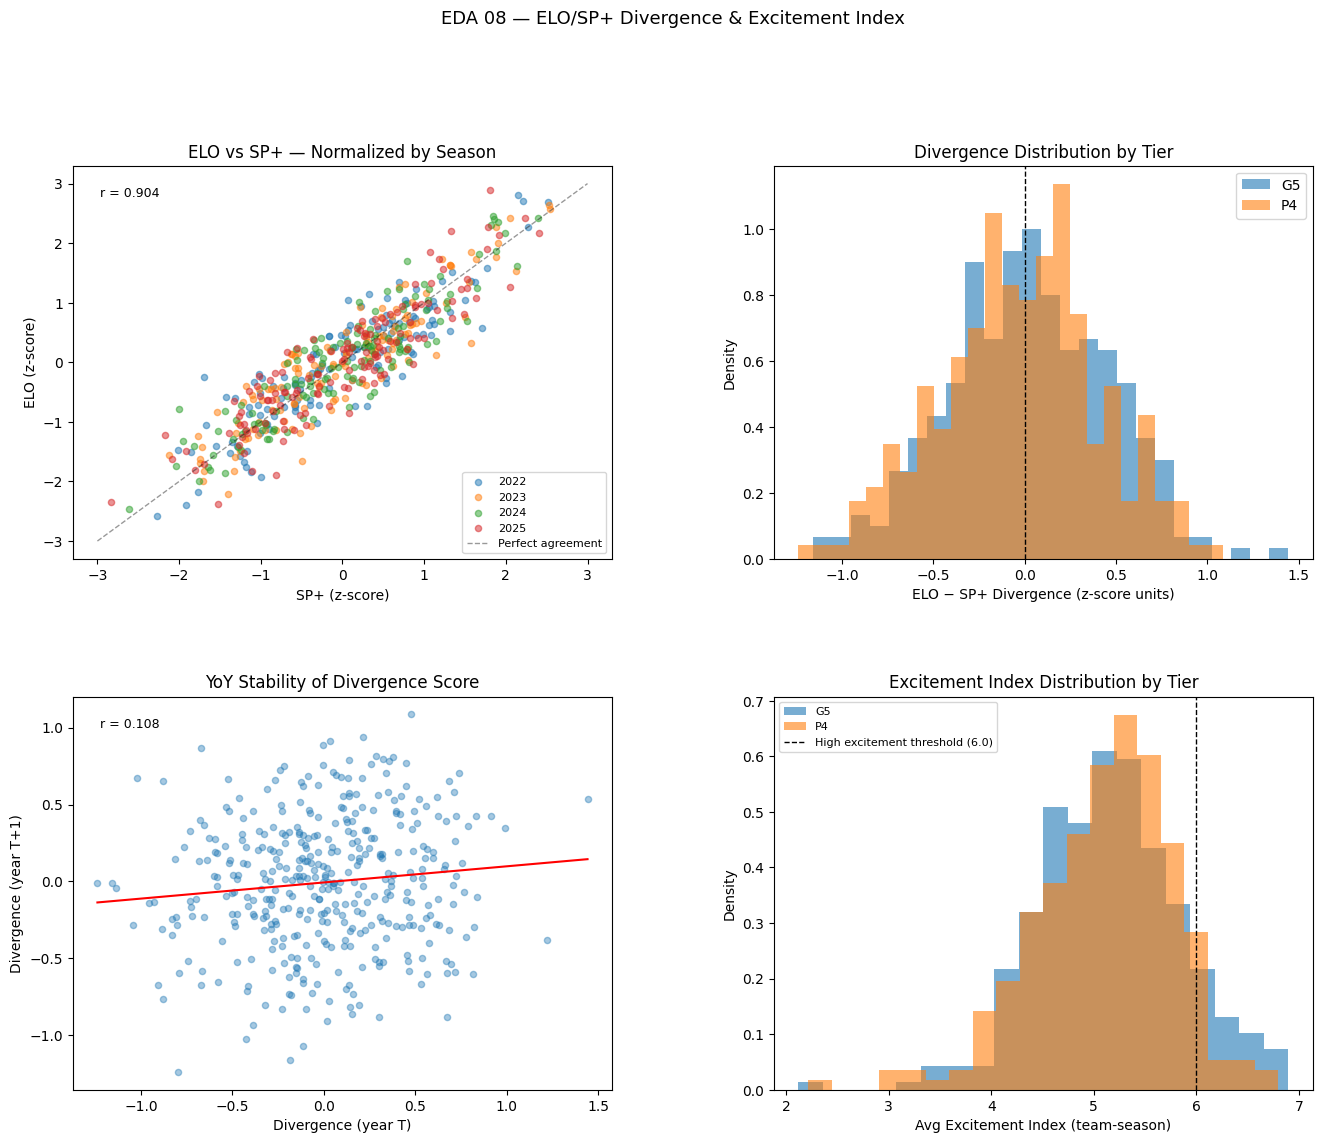

In [11]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Panel 1: ELO vs SP+ by season (normalized z-scores)
ax1 = fig.add_subplot(gs[0, 0])
colors = {'2022': '#1f77b4', '2023': '#ff7f0e', '2024': '#2ca02c', '2025': '#d62728'}
for season, grp in ts.groupby('season'):
    ax1.scatter(grp['sp_rating_z'], grp['mean_pregame_elo_z'],
                alpha=0.5, s=20, label=str(season), color=colors.get(str(season), 'gray'))
lims = [-3, 3]
ax1.plot(lims, lims, 'k--', lw=1, alpha=0.4, label='Perfect agreement')
ax1.set_xlabel('SP+ (z-score)')
ax1.set_ylabel('ELO (z-score)')
ax1.set_title('ELO vs SP+ — Normalized by Season')
ax1.legend(fontsize=8)
r_raw, _ = stats.pearsonr(ts['sp_rating_z'], ts['mean_pregame_elo_z'])
ax1.text(0.05, 0.92, f'r = {r_raw:.3f}', transform=ax1.transAxes, fontsize=9)

# Panel 2: Divergence distribution by tier
ax2 = fig.add_subplot(gs[0, 1])
ts_tier = ts.merge(conf_map[['team_name', 'season', 'tier']].drop_duplicates(), on=['team_name', 'season'], how='left')
for tier, grp in ts_tier.groupby('tier'):
    ax2.hist(grp['elo_sp_divergence'], bins=25, alpha=0.6, label=tier, density=True)
ax2.axvline(0, color='black', lw=1, linestyle='--')
ax2.set_xlabel('ELO − SP+ Divergence (z-score units)')
ax2.set_ylabel('Density')
ax2.set_title('Divergence Distribution by Tier')
ax2.legend()

# Panel 3: Divergence YoY scatter
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(yoy['elo_sp_divergence'], yoy['divergence_next'], alpha=0.4, s=20)
m, b, r_val, _, _ = stats.linregress(yoy['elo_sp_divergence'], yoy['divergence_next'])
x_line = np.linspace(yoy['elo_sp_divergence'].min(), yoy['elo_sp_divergence'].max(), 100)
ax3.plot(x_line, m * x_line + b, 'r-', lw=1.5)
ax3.set_xlabel('Divergence (year T)')
ax3.set_ylabel('Divergence (year T+1)')
ax3.set_title('YoY Stability of Divergence Score')
ax3.text(0.05, 0.92, f'r = {r_div_yoy:.3f}', transform=ax3.transAxes, fontsize=9)

# Panel 4: Excitement index by tier
ax4 = fig.add_subplot(gs[1, 1])
exc_tier = exc_season.merge(conf_map[['team_name', 'season', 'tier']].drop_duplicates(), on=['team_name', 'season'], how='left')
for tier, grp in exc_tier.dropna(subset=['tier']).groupby('tier'):
    ax4.hist(grp['avg_excitement_index'], bins=20, alpha=0.6, label=tier, density=True)
ax4.axvline(6.0, color='black', lw=1, linestyle='--', label='High excitement threshold (6.0)')
ax4.set_xlabel('Avg Excitement Index (team-season)')
ax4.set_ylabel('Density')
ax4.set_title('Excitement Index Distribution by Tier')
ax4.legend(fontsize=8)

plt.suptitle('EDA 08 — ELO/SP+ Divergence & Excitement Index', fontsize=13, y=1.01)
plt.show()

In [13]:
import csv, os

print("=" * 65)
print("EDA 08 — VERDICT SUMMARY")
print("=" * 65)

print(f"""
DIVERGENCE (ELO − SP+ normalized):
  YoY stability:          r = {r_div_yoy:.3f}  (p = {p_div_yoy:.4f})
  Partial r → next win%:  r = {r_partial_winpct:.3f}  (p = {p_partial_winpct:.4f})
  Partial r → next SP+:   r = {r_partial_sp:.3f}  (p = {p_partial_sp:.4f})
  Benchmark SP+ → win%:   r = {r_sp_winpct:.3f}  (p = {p_sp_winpct:.4f})

EXCITEMENT INDEX:
  Avg excitement partial r → next win%:      r = {r_avg_partial:.3f}  (p = {p_avg_partial:.4f})
  Pct high excitement partial r → next win%: r = {r_hi_partial:.3f}  (p = {p_hi_partial:.4f})

INTERACTION (divergence × excitement):
  Divergence ↔ avg excitement:        r = {r_div_exc:.3f}  (p = {p_div_exc:.4f})
  Divergence ↔ pct high excitement:   r = {r_div_hi:.3f}  (p = {p_div_hi:.4f})

DECISION THRESHOLD: partial r >= 0.10 to enter candidate list
""")

verdict_data = [
    ['feature', 'partial_r', 'p_value', 'yoy_stability_r', 'keep', 'notes'],
    ['elo_sp_divergence',
     round(r_partial_winpct, 4), round(p_partial_winpct, 4),
     round(r_div_yoy, 4),
     'TBD — see partial r vs 0.10 threshold',
     'Normalized ELO minus SP+ z-score; compute in notebook; add to dbt only if keep=True'],
    ['avg_excitement_index',
     round(r_avg_partial, 4), round(p_avg_partial, 4),
     'n/a',
     'False',
     'Partial r=-0.034 after EPA control — no signal, below 0.10 threshold'],
    ['pct_games_high_excitement',
     round(r_hi_partial, 4), round(p_hi_partial, 4),
     'n/a',
     'False',
     'Partial r=-0.040 after EPA control — no signal, below 0.10 threshold'],
]

os.makedirs(os.path.expanduser('~/cfb-analytics/artifacts'), exist_ok=True)
verdict_path = os.path.expanduser('~/cfb-analytics/artifacts/elo_excitement_verdict.csv')
with open(verdict_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(verdict_data)

print(f"Wrote {verdict_path}")
print("\nUpdate elo_sp_divergence keep=True/False once divergence numbers are in.")

EDA 08 — VERDICT SUMMARY

DIVERGENCE (ELO − SP+ normalized):
  YoY stability:          r = 0.108  (p = 0.0311)
  Partial r → next win%:  r = 0.059  (p = 0.2442)
  Partial r → next SP+:   r = 0.078  (p = 0.1216)
  Benchmark SP+ → win%:   r = 0.496  (p = 0.0000)

EXCITEMENT INDEX:
  Avg excitement partial r → next win%:      r = -0.034  (p = 0.5049)
  Pct high excitement partial r → next win%: r = -0.040  (p = 0.4282)

INTERACTION (divergence × excitement):
  Divergence ↔ avg excitement:        r = 0.031  (p = 0.4715)
  Divergence ↔ pct high excitement:   r = 0.035  (p = 0.4241)

DECISION THRESHOLD: partial r >= 0.10 to enter candidate list

Wrote /Users/kevinjohnson/cfb-analytics/artifacts/elo_excitement_verdict.csv

Update elo_sp_divergence keep=True/False once divergence numbers are in.
